# Train an MLP baseline on IBL Brain Wide Map data

In this notebook we train a **Multi-Layer Perceptron (MLP)** from scratch to decode animal behavior
(e.g. wheel velocity) spiking activity in relevant brain areas.

**Experiment**: we train three separate models, each restricted to a different subset of
units selected by brain region:
- **motor** — primary and secondary motor cortex units
- **caudoputamen** — striatal units
- **both** — motor + caudoputamen combined

**Notebook outline:**

1. **Dataset** — Load the processed HDF5 recordings (produced by the previous pipeline notebook) and set up train / validation / test `DataLoader`s.
2. **Register the output modality** — Declare `wheel_velocity` as the decoding target in the `torch_brain` modality registry.
3. **Hyperparameters** — Set binning resolution, window length, model size, and training constants.
4. **Train one MLP per brain-region subset** — Filter units by area, build a separate `MLPNeuralDecoder` for each region subset, and train with a standard MSE loop.
5. **Test set evaluation and comparison** — Run inference on held-out data, compute Pearson r per interval, and compare the three models with violin plots and time-series visualizations.



In [1]:
from pathlib import Path
import numpy as np
import torch
import torch_brain
from torch_brain.registry import MODALITY_REGISTRY, DataType
from torch_brain.transforms import UnitFilter, Compose

from mlp import MLPNeuralDecoder
from aux_functions import (
    get_loaders,
    get_unit_ids,
    move_to_device,
    pearson_r,
    compute_r2,
    training_step,
    plot_training_curves,
    plot_test_intervals,
)

## 1. Dataset

The processed neural recordings were produced in the previous notebook using the `brainsets`
pipeline, which downloads the raw IBL Brain Wide Map data from DANDI and converts it into
structured HDF5 files stored under `ibl_processed/`. Each file corresponds to one session
and contains spike times, unit metadata, behavioral signals, and pre-defined `train` / `valid`
/ `test` time domains.

The utility function `get_loaders` wraps the selected sessions into a `Dataset` and returns three `DataLoaders`, one per split.

In [2]:
# List of recording IDs to use (h5 file stems, without the .h5 extension)
recording_ids = [
    "sub-CSHL059_ses-d2f5a130-b981-4546-8858-c94ae1da75ff_desc-processed_behavior+ecephys",
    #"sub-NYU-21_ses-8c33abef-3d3e-4d42-9f27-445e9def08f9_desc-processed_behavior+ecephys",
    #"sub-UCLA035_ses-6f36868f-5cc1-450c-82fa-6b9829ce0cfe_desc-processed_behavior+ecephys",
    #"sub-DY-011_ses-7bee9f09-a238-42cf-b499-f51f765c6ded_desc-processed_behavior+ecephys",
    #"sub-DY-014_ses-bd456d8f-d36e-434a-8051-ff3997253802_desc-processed_behavior+ecephys",
    #"sub-NR-0027_ses-ae8787b1-4229-4d56-b0c2-566b61a25b77_desc-processed_behavior+ecephys",
    #"sub-SWC-038_ses-03063955-2523-47bd-ae57-f7489dd40f15_desc-processed_behavior+ecephys",
    #"sub-ZFM-01936_ses-4aa1d525-5c7d-4c50-a147-ec53a9014812_desc-processed_behavior+ecephys",
    #"sub-CSH-ZAD-026_ses-81a78eac-9d36-4f90-a73a-7eb3ad7f770b_desc-processed_behavior+ecephys",
    #"sub-CSH-ZAD-026_ses-626126d5-eecf-4e9b-900e-ec29a17ece07_desc-processed_behavior+ecephys",
    #"sub-CSH-ZAD-026_ses-b69b86be-af7d-4ecf-8cbf-0cd356afa1bd_desc-processed_behavior+ecephys",
    #"sub-CSH-ZAD-026_ses-e56541a5-a6d5-4750-b1fe-f6b5257bfe7c_desc-processed_behavior+ecephys",
]

dir_path = Path(".").resolve()

dataset, train_loader, val_loader, test_loader = get_loaders(
    dir_path=dir_path,
    recording_ids=recording_ids,
    readout_id="wheel_velocity",
    window_length=1.0,
    batch_size=16,
)

print(f"Recordings  : {len(dataset.recording_ids)}")
print(f"Total units : {len(dataset.get_unit_ids())}")

Recordings  : 1
Total units : 1669


## 2. Register the output modality

`torch_brain` uses a global modality registry to declare what a model should predict: the
attribute paths in the data where target values and their timestamps live, the output dimension,
and the loss function. Here we register `wheel_velocity` as a 1-D continuous signal decoded
with MSE loss.

The resulting `readout_spec` is passed to `MLPNeuralDecoder` to configure its output layer and
to `model.tokenize` to know which field to extract from each data slice. The `if` guard makes
the cell safe to re-run without raising a duplicate-registration error.

In [3]:
# Only register if not already registered (safe for re-running the cell)
if "wheel_velocity" not in MODALITY_REGISTRY:
    torch_brain.register_modality(
        name="wheel_velocity",
        dim=1,
        type=DataType.CONTINUOUS,
        timestamp_key="wheel_velocity.timestamps",
        value_key="wheel_velocity.values",
        loss_fn=torch_brain.nn.loss.MSELoss(),
    )

readout_spec = MODALITY_REGISTRY["wheel_velocity"]
print(readout_spec)

ModalitySpec(id=20, dim=1, type=<DataType.CONTINUOUS: 0>, timestamp_key='wheel_velocity.timestamps', value_key='wheel_velocity.values', loss_fn=MSELoss())


## 3. Hyperparameters

The following constants control the model architecture and training:

- **`BIN_SIZE`** — Width of each spike-count bin on the input side (10 ms → 100 bins per second of recording).
- **`SEQUENCE_LENGTH`** — Duration of each training/evaluation window in seconds.
- **`READOUT_RATE`** — Native sampling rate of the wheel velocity signal in Hz; sets the number of output prediction steps per window.
- **`HIDDEN_DIM`** — Number of neurons in the MLP hidden layer.
- **`NUM_EPOCHS`** — Number of full passes over the training set.
- **`LR`** — Learning rate for the AdamW optimizer.
- **`QUALITY_SCORE`** — IBL single-unit quality threshold; only units above this value are included when filtering by brain region in Section 4.

In [4]:
device = (
    torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cuda:0") if torch.cuda.is_available()
    else torch.device("cpu")
)
print(f"Using device: {device}")

BIN_SIZE        = 10e-3    # 10 ms  → 100 input bins / second
SEQUENCE_LENGTH = 1.0      # 1-second context window
READOUT_RATE    = 1000.0   # Hz  → 1000 output steps / second
HIDDEN_DIM      = 256
NUM_EPOCHS      = 30
LR              = 5e-4
QUALITY_SCORE   = 0.6      # IBL quality score threshold

Using device: mps


## 4. Train one MLP per brain-region subset

We train **three separate MLP models**, each receiving spikes from a different subset of
recorded units selected by brain region:

| Experiment | Region filter | Key question |
|---|---|---|
| **4a. motor** | Primary & secondary motor cortex | Motor cortex alone is sufficient to decode wheel velocity? |
| **4b. caudoputamen** | Striatum (caudoputamen) | Striatal activity also encodes wheel kinematics? |
| **4c. both** | Motor + caudoputamen combined | Does adding more regions improve decoding? |

Unlike POYO — which uses an infinite-vocabulary unit embedding and can handle any set of units at
inference time — the MLP bakes `num_units` directly into its first linear layer. This means the unit count must be fixed before the model is constructed.

The workflow for each experiment is therefore:

1. `get_unit_ids(dataset, filter_str=..., quality_score=...)` → list of valid unit IDs, given the filter parameters
2. `UnitFilter(mask_fn=..., field="spikes", reset_index=True)` → drops unwanted units and
   remaps `spikes.unit_index` to `0 … N_filtered-1`
3. `MLPNeuralDecoder(num_units=N_filtered, ...)` → model parametrized for that unit count
4. `dataset.transform = Compose([unit_filter, model.tokenize])` → apply filter then tokenize
5. Standard training loop with `training_step` / `compute_r2`

Results are stored in shared dicts (`trained_models`, `unit_filters`, …) for the comparison in
Section 5.

In [5]:
# Shared containers — populated by each sub-section below
trained_models   = {}   # label -> trained MLPNeuralDecoder
unit_filters     = {}   # label -> UnitFilter transform
r2_logs_by_exp   = {}   # label -> val R² log (for training curves)
loss_logs_by_exp = {}   # label -> training loss log

### 4a. Motor cortex

Units in **primary and secondary motor cortex** (location name contains `"motor"`). These areas
are directly involved in planning and executing voluntary movements, so we expect a strong
correlation with wheel velocity.

In [6]:
LABEL = "motor"
FILTER_STRS = ["motor"]

# 1. Filter unit IDs by region and quality
unit_ids_motor = get_unit_ids(dataset, filter_str=FILTER_STRS, quality_score=QUALITY_SCORE)
print(f"Motor units (quality > {QUALITY_SCORE}): {len(unit_ids_motor)}")

# 2. Build UnitFilter — keeps only selected units, remaps spike indices
valid_set_motor = set(unit_ids_motor)
unit_filter_motor = UnitFilter(
    mask_fn=lambda units, vs=valid_set_motor: np.array([uid in vs for uid in units.id]),
    field="spikes",
    reset_index=True,
)
unit_filters[LABEL] = unit_filter_motor

# 3. Build MLP with the filtered unit count
model_motor = MLPNeuralDecoder(
    num_units=len(unit_ids_motor),
    bin_size=BIN_SIZE,
    sequence_length=SEQUENCE_LENGTH,
    readout_spec=readout_spec,
    readout_sampling_rate=READOUT_RATE,
    hidden_dim=HIDDEN_DIM,
).to(device).float()

# 4. Chain transforms: filter → tokenize
dataset.transform = Compose([unit_filter_motor, model_motor.tokenize])

# 5. Train
opt_motor = torch.optim.AdamW(model_motor.parameters(), lr=LR)
r2_log_motor, loss_log_motor = [], []

for epoch in range(NUM_EPOCHS):
    val_r2, _, _ = compute_r2(val_loader, model_motor)
    r2_log_motor.append(val_r2)

    model_motor.train()
    epoch_loss = 0.0
    for batch in train_loader:
        batch = move_to_device(batch, device)
        loss = training_step(batch, model_motor, opt_motor)
        loss_log_motor.append(loss.item())
        epoch_loss += loss.item()
    print(f"  Epoch {epoch+1:3d}/{NUM_EPOCHS}  loss={epoch_loss/len(train_loader):.4f}  val_R²={val_r2:.3f}")

final_r2, _, _ = compute_r2(val_loader, model_motor)
r2_log_motor.append(final_r2)
print(f"✅ Motor — final val R² = {final_r2:.3f}")

trained_models[LABEL]   = model_motor
r2_logs_by_exp[LABEL]   = r2_log_motor
loss_logs_by_exp[LABEL] = loss_log_motor

Motor units (quality > 0.6): 265
  Epoch   1/30  loss=1.9735  val_R²=-0.031
  Epoch   2/30  loss=1.5246  val_R²=0.239
  Epoch   3/30  loss=1.3803  val_R²=0.278
  Epoch   4/30  loss=1.2086  val_R²=0.337
  Epoch   5/30  loss=1.0823  val_R²=0.426
  Epoch   6/30  loss=1.0105  val_R²=0.433
  Epoch   7/30  loss=1.0042  val_R²=0.438
  Epoch   8/30  loss=0.8571  val_R²=0.504
  Epoch   9/30  loss=0.8500  val_R²=0.498
  Epoch  10/30  loss=0.7765  val_R²=0.471
  Epoch  11/30  loss=0.8003  val_R²=0.486
  Epoch  12/30  loss=0.7163  val_R²=0.513
  Epoch  13/30  loss=0.6997  val_R²=0.541
  Epoch  14/30  loss=0.6653  val_R²=0.538
  Epoch  15/30  loss=0.6674  val_R²=0.563
  Epoch  16/30  loss=0.6377  val_R²=0.557
  Epoch  17/30  loss=0.6196  val_R²=0.565
  Epoch  18/30  loss=0.5885  val_R²=0.537
  Epoch  19/30  loss=0.5838  val_R²=0.547
  Epoch  20/30  loss=0.5397  val_R²=0.553
  Epoch  21/30  loss=0.5446  val_R²=0.569
  Epoch  22/30  loss=0.5211  val_R²=0.558
  Epoch  23/30  loss=0.4954  val_R²=0.579


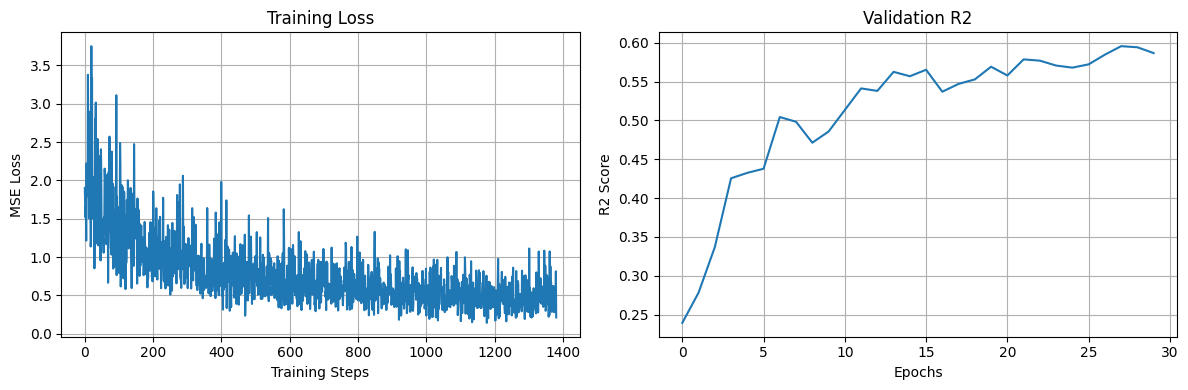

In [7]:
plot_training_curves(r2_log_motor, loss_log_motor)

### 4b. Caudoputamen (striatum)

Units in the **caudoputamen** — the dorsal striatum. This region is part of the basal ganglia
and is involved in action selection and motor control. It receives strong projections from motor
cortex, so its activity may also correlate with wheel kinematics.

In [8]:
LABEL = "caudoputamen"
FILTER_STRS = ["caudoputamen"]

unit_ids_cp = get_unit_ids(dataset, filter_str=FILTER_STRS, quality_score=QUALITY_SCORE)
print(f"Caudoputamen units (quality > {QUALITY_SCORE}): {len(unit_ids_cp)}")

valid_set_cp = set(unit_ids_cp)
unit_filter_cp = UnitFilter(
    mask_fn=lambda units, vs=valid_set_cp: np.array([uid in vs for uid in units.id]),
    field="spikes",
    reset_index=True,
)
unit_filters[LABEL] = unit_filter_cp

model_cp = MLPNeuralDecoder(
    num_units=len(unit_ids_cp),
    bin_size=BIN_SIZE,
    sequence_length=SEQUENCE_LENGTH,
    readout_spec=readout_spec,
    readout_sampling_rate=READOUT_RATE,
    hidden_dim=HIDDEN_DIM,
).to(device).float()

dataset.transform = Compose([unit_filter_cp, model_cp.tokenize])

opt_cp = torch.optim.AdamW(model_cp.parameters(), lr=LR)
r2_log_cp, loss_log_cp = [], []

for epoch in range(NUM_EPOCHS):
    val_r2, _, _ = compute_r2(val_loader, model_cp)
    r2_log_cp.append(val_r2)

    model_cp.train()
    epoch_loss = 0.0
    for batch in train_loader:
        batch = move_to_device(batch, device)
        loss = training_step(batch, model_cp, opt_cp)
        loss_log_cp.append(loss.item())
        epoch_loss += loss.item()
    print(f"  Epoch {epoch+1:3d}/{NUM_EPOCHS}  loss={epoch_loss/len(train_loader):.4f}  val_R²={val_r2:.3f}")

final_r2, _, _ = compute_r2(val_loader, model_cp)
r2_log_cp.append(final_r2)
print(f"✅ Caudoputamen — final val R² = {final_r2:.3f}")

trained_models[LABEL]   = model_cp
r2_logs_by_exp[LABEL]   = r2_log_cp
loss_logs_by_exp[LABEL] = loss_log_cp

Caudoputamen units (quality > 0.6): 345
  Epoch   1/30  loss=2.0275  val_R²=-0.031
  Epoch   2/30  loss=1.5283  val_R²=0.252
  Epoch   3/30  loss=1.3177  val_R²=0.312
  Epoch   4/30  loss=1.2066  val_R²=0.430
  Epoch   5/30  loss=1.1276  val_R²=0.368
  Epoch   6/30  loss=0.9775  val_R²=0.473
  Epoch   7/30  loss=0.8899  val_R²=0.494
  Epoch   8/30  loss=0.8732  val_R²=0.501
  Epoch   9/30  loss=0.8701  val_R²=0.488
  Epoch  10/30  loss=0.7945  val_R²=0.503
  Epoch  11/30  loss=0.7841  val_R²=0.521
  Epoch  12/30  loss=0.7377  val_R²=0.518
  Epoch  13/30  loss=0.6938  val_R²=0.497
  Epoch  14/30  loss=0.6493  val_R²=0.516
  Epoch  15/30  loss=0.6428  val_R²=0.525
  Epoch  16/30  loss=0.6410  val_R²=0.513
  Epoch  17/30  loss=0.5903  val_R²=0.513
  Epoch  18/30  loss=0.5990  val_R²=0.524
  Epoch  19/30  loss=0.5808  val_R²=0.526
  Epoch  20/30  loss=0.5492  val_R²=0.543
  Epoch  21/30  loss=0.5348  val_R²=0.531
  Epoch  22/30  loss=0.5490  val_R²=0.555
  Epoch  23/30  loss=0.5524  val_R²

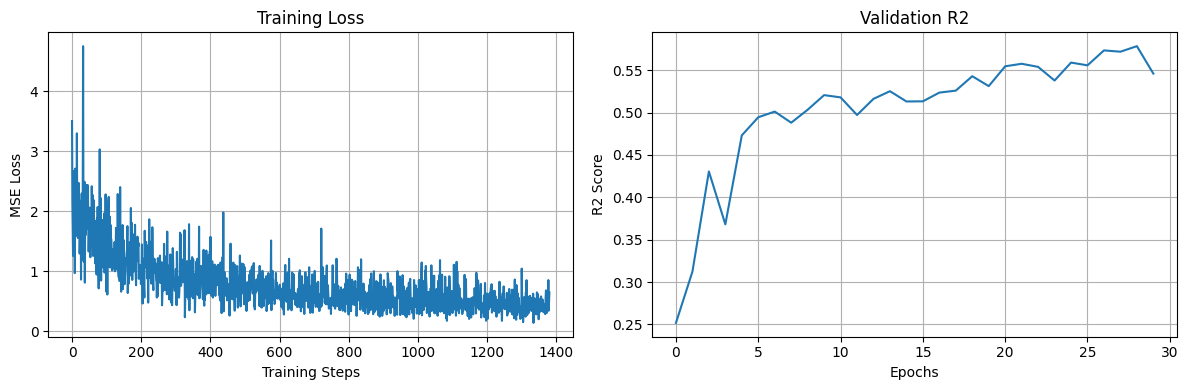

In [9]:
plot_training_curves(r2_log_cp, loss_log_cp)

### 4c. Both regions combined

Combine all **motor cortex + caudoputamen** units into a single input. With more units the
model's input layer is larger (`num_input_bins × (N_motor + N_cp)`), giving it access to
complementary signals from both regions.

In [10]:
LABEL = "both"
FILTER_STRS = ["motor", "caudoputamen"]

unit_ids_both = get_unit_ids(dataset, filter_str=FILTER_STRS, quality_score=QUALITY_SCORE)
print(f"Motor + caudoputamen units (quality > {QUALITY_SCORE}): {len(unit_ids_both)}")

valid_set_both = set(unit_ids_both)
unit_filter_both = UnitFilter(
    mask_fn=lambda units, vs=valid_set_both: np.array([uid in vs for uid in units.id]),
    field="spikes",
    reset_index=True,
)
unit_filters[LABEL] = unit_filter_both

model_both = MLPNeuralDecoder(
    num_units=len(unit_ids_both),
    bin_size=BIN_SIZE,
    sequence_length=SEQUENCE_LENGTH,
    readout_spec=readout_spec,
    readout_sampling_rate=READOUT_RATE,
    hidden_dim=HIDDEN_DIM,
).to(device).float()

dataset.transform = Compose([unit_filter_both, model_both.tokenize])

opt_both = torch.optim.AdamW(model_both.parameters(), lr=LR)
r2_log_both, loss_log_both = [], []

for epoch in range(NUM_EPOCHS):
    val_r2, _, _ = compute_r2(val_loader, model_both)
    r2_log_both.append(val_r2)

    model_both.train()
    epoch_loss = 0.0
    for batch in train_loader:
        batch = move_to_device(batch, device)
        loss = training_step(batch, model_both, opt_both)
        loss_log_both.append(loss.item())
        epoch_loss += loss.item()
    print(f"  Epoch {epoch+1:3d}/{NUM_EPOCHS}  loss={epoch_loss/len(train_loader):.4f}  val_R²={val_r2:.3f}")

final_r2, _, _ = compute_r2(val_loader, model_both)
r2_log_both.append(final_r2)
print(f"✅ Both — final val R² = {final_r2:.3f}")

trained_models[LABEL]   = model_both
r2_logs_by_exp[LABEL]   = r2_log_both
loss_logs_by_exp[LABEL] = loss_log_both

Motor + caudoputamen units (quality > 0.6): 610
  Epoch   1/30  loss=1.9665  val_R²=-0.031
  Epoch   2/30  loss=1.5745  val_R²=0.252
  Epoch   3/30  loss=1.2008  val_R²=0.350
  Epoch   4/30  loss=1.1225  val_R²=0.411
  Epoch   5/30  loss=1.0232  val_R²=0.483
  Epoch   6/30  loss=0.8513  val_R²=0.449
  Epoch   7/30  loss=0.8019  val_R²=0.525
  Epoch   8/30  loss=0.7686  val_R²=0.510
  Epoch   9/30  loss=0.7168  val_R²=0.525
  Epoch  10/30  loss=0.6876  val_R²=0.556
  Epoch  11/30  loss=0.6443  val_R²=0.561
  Epoch  12/30  loss=0.6429  val_R²=0.561
  Epoch  13/30  loss=0.6070  val_R²=0.557
  Epoch  14/30  loss=0.5972  val_R²=0.576
  Epoch  15/30  loss=0.5409  val_R²=0.573
  Epoch  16/30  loss=0.5433  val_R²=0.573
  Epoch  17/30  loss=0.5161  val_R²=0.600
  Epoch  18/30  loss=0.5110  val_R²=0.586
  Epoch  19/30  loss=0.4728  val_R²=0.584
  Epoch  20/30  loss=0.4600  val_R²=0.620
  Epoch  21/30  loss=0.4841  val_R²=0.592
  Epoch  22/30  loss=0.4257  val_R²=0.606
  Epoch  23/30  loss=0.4223

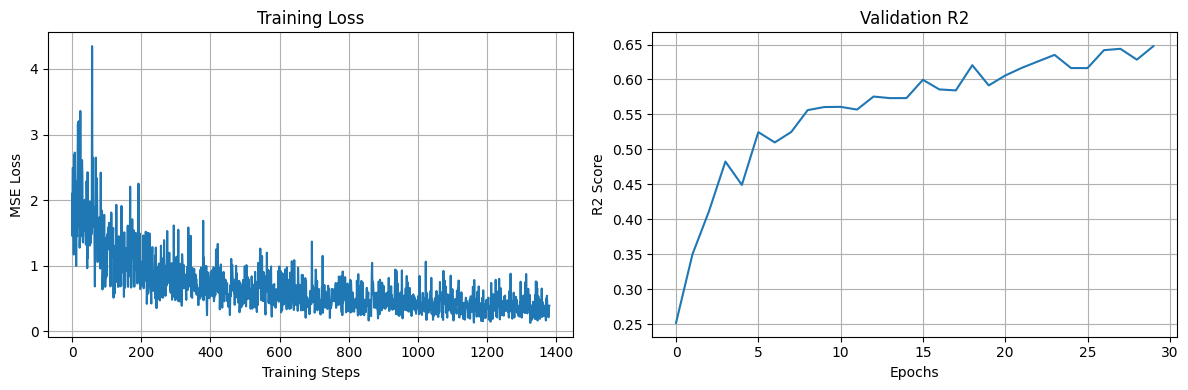

In [11]:
plot_training_curves(r2_log_both, loss_log_both)

## 5. Test set evaluation and comparison

With the three models trained, we now evaluate them on held-out **test data** — a portion of
the recording that was never seen during training or validation.

For each model the appropriate `UnitFilter + tokenize` transform is re-applied to the shared
dataset, inference is run over all test windows, and **Pearson r** is computed per 1-second
interval. Results are then compared across models with a violin plot of the per-interval r
distribution and side-by-side time-series plots of the best and worst decoded intervals.

In [12]:
test_results = {}  # label -> {targets, preds, r2_scores}

for label, m in trained_models.items():
    m.eval()
    # Restore the unit filter + tokenize transform for this model
    dataset.transform = Compose([unit_filters[label], m.tokenize])

    targets, preds, r2_scores = [], [], []
    with torch.no_grad():
        for batch in test_loader:
            batch  = move_to_device(batch, device)
            pred   = m(**batch["model_inputs"]).squeeze(-1)   # (B, T_out)
            target = batch["target_values"]                    # (B, T_out)

            for i in range(pred.shape[0]):
                r = pearson_r(pred[i], target[i])
                preds.append(pred[i])
                targets.append(target[i])
                r2_scores.append(r.item())

    median_r2 = float(np.nanmedian(r2_scores))
    mean_r2   = float(np.nanmean(r2_scores))
    print(f"{label:15s}  Test R²  median={median_r2:.3f}   mean={mean_r2:.3f}")
    test_results[label] = dict(targets=targets, preds=preds, r2_scores=r2_scores)

motor            Test R²  median=0.649   mean=0.521
caudoputamen     Test R²  median=0.558   mean=0.463
both             Test R²  median=0.723   mean=0.579


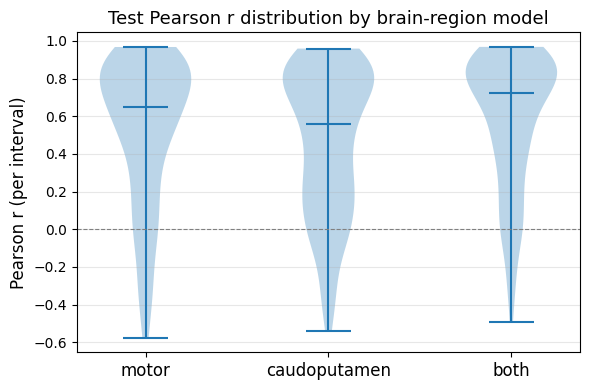

motor            n= 201  median=0.649  mean=0.521  std=0.392
caudoputamen     n= 201  median=0.558  mean=0.463  std=0.388
both             n= 201  median=0.723  mean=0.579  std=0.354


In [13]:
# Summary: R² distribution per brain-region model
import matplotlib.pyplot as plt

labels = list(test_results.keys())
r2_data = [
    np.array(test_results[lb]["r2_scores"])
    for lb in labels
]
# Remove NaN for cleaner plots
r2_clean = [arr[~np.isnan(arr)] for arr in r2_data]

fig, ax = plt.subplots(figsize=(6, 4))
parts = ax.violinplot(r2_clean, showmedians=True, showextrema=True)
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, fontsize=12)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_ylabel("Pearson r (per interval)", fontsize=12)
ax.set_title("Test Pearson r distribution by brain-region model", fontsize=13)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

for lb, arr in zip(labels, r2_clean):
    print(f"{lb:15s}  n={len(arr):4d}  "
          f"median={np.median(arr):.3f}  mean={np.mean(arr):.3f}  std={np.std(arr):.3f}")

Let's visualize how each model performs in decoding the wheel velocity. Intervals with significant wheel movement are relatively well decoded by the models, with marginal improvement when combining units from both regions. The models fail to decode low or no movement intervals.

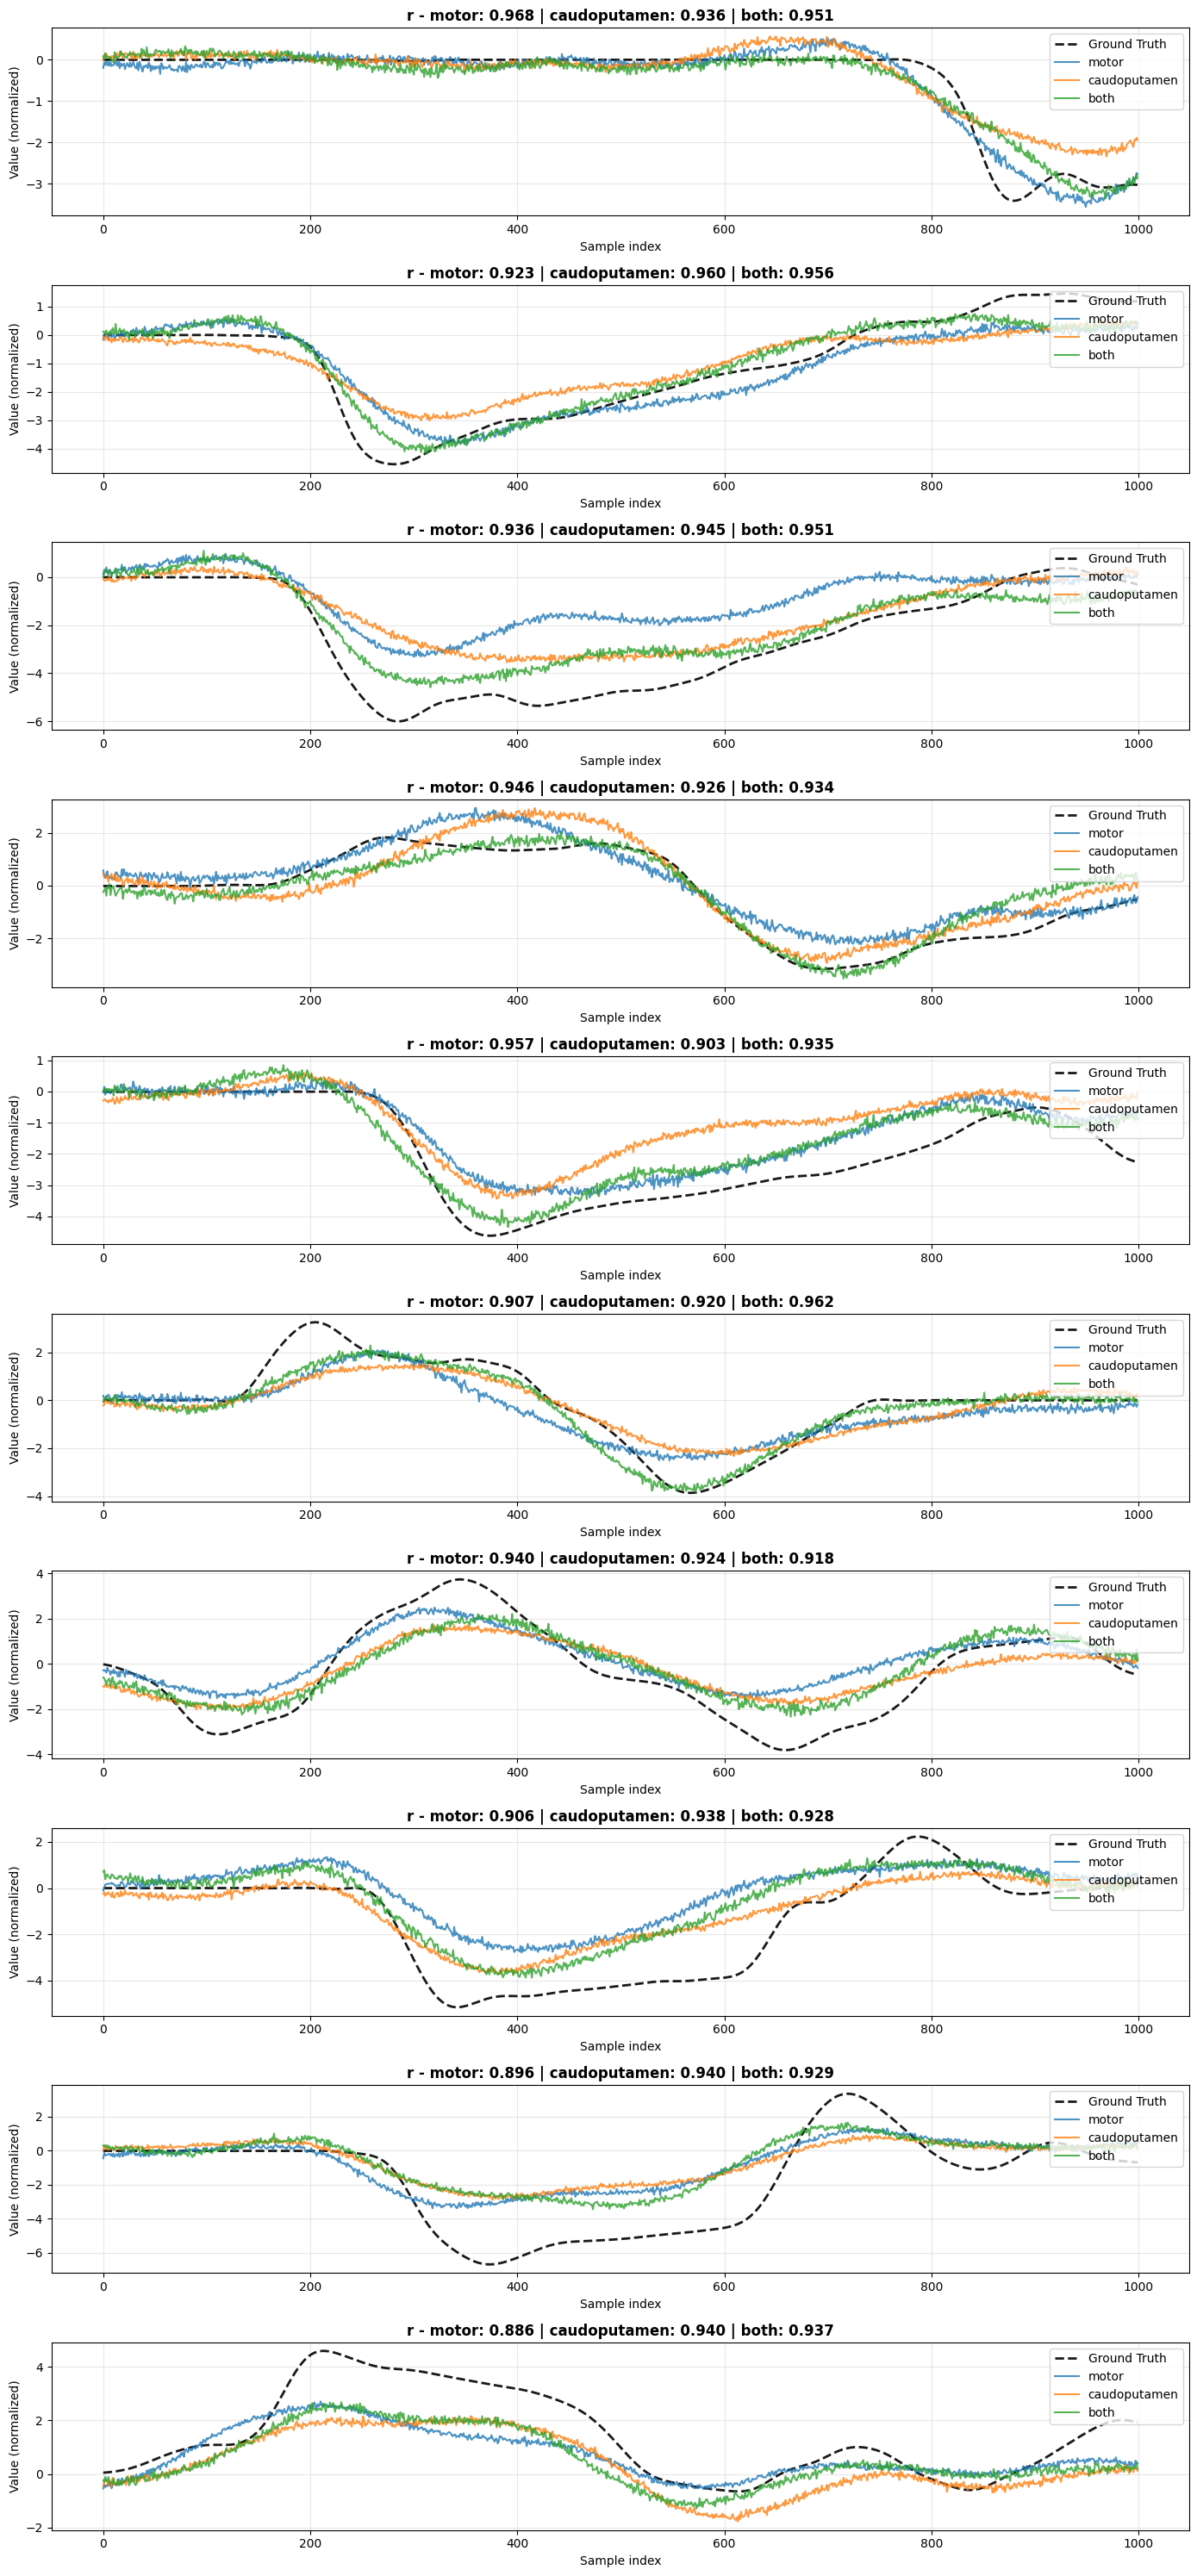

In [14]:
plot_test_intervals(
    test_results=test_results,
    n_intervals=10,
    order="top",
)

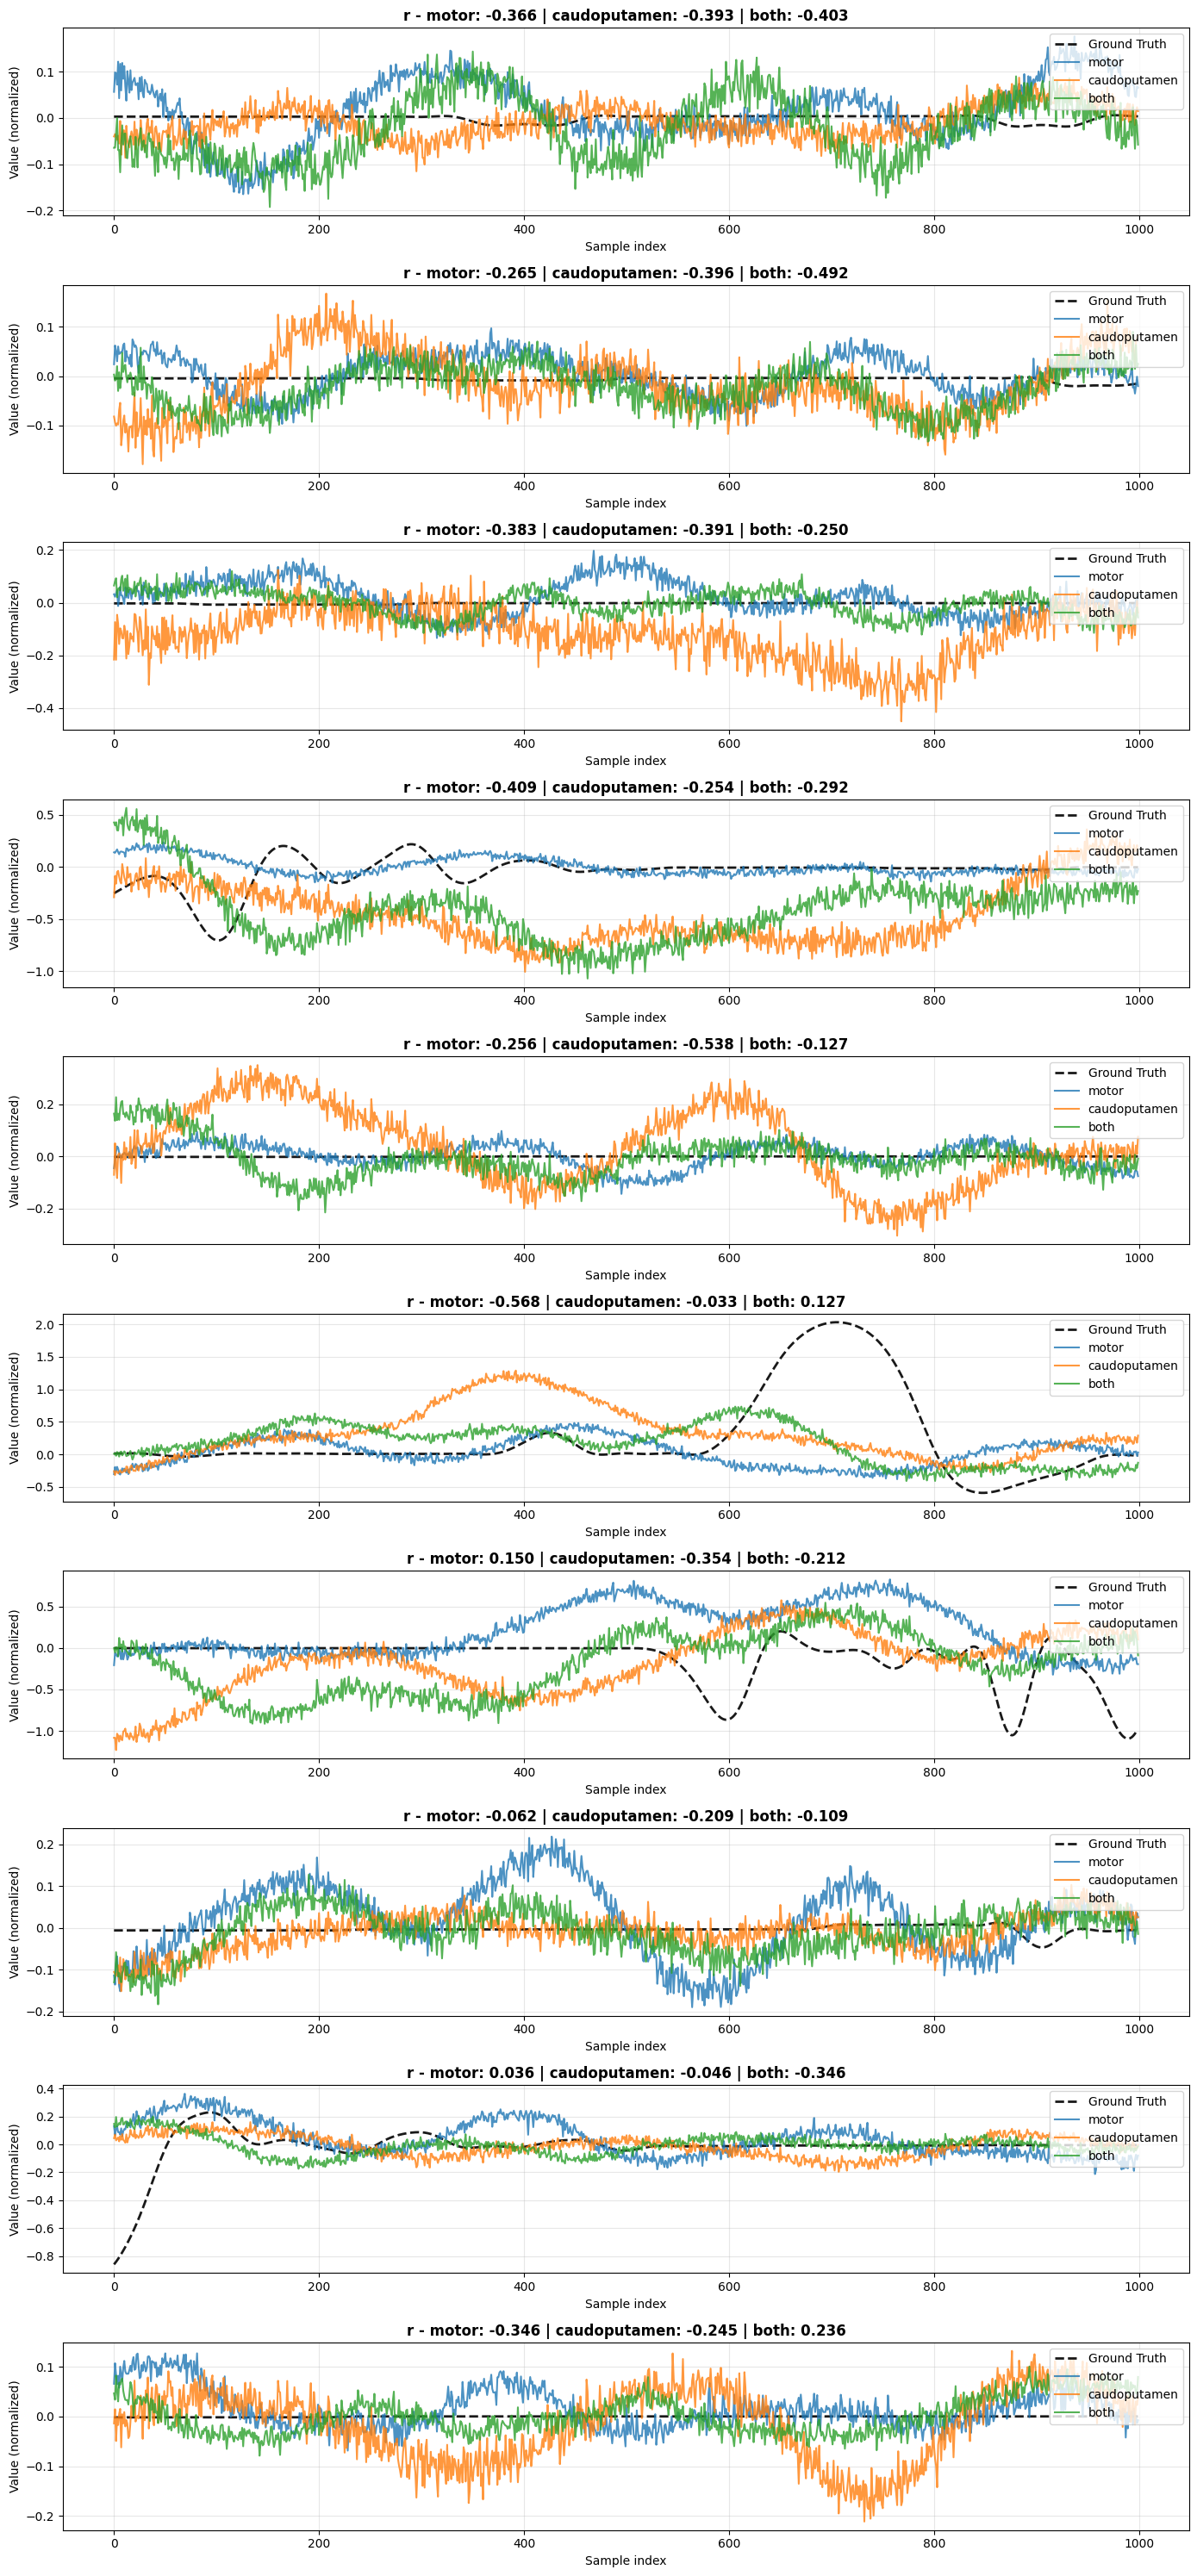

In [15]:
plot_test_intervals(
    test_results=test_results,
    n_intervals=10,
    order="bottom",
)